### Prior predictive checks for the MA nonessential AMPK model

**Background (Linden-Santangeli, 2025):** Prior elicitation was performed for AMPK signaling models to ensure reasonable prior predictive densities. The process involved:
1. **Direct elicitation** using PreliZ's maximum entropy method to set LogNormal prior parameters with 90% of mass within literature-based bounds.
2. **Predictive elicitation** to iteratively refine priors so that prior predictive simulations exhibit the expected sigmoidal AMPK sensor response: near-zero initial activation, increasing activation rate, and full steady-state sensor activation.

Key constraints identified:
- Initial phosphorylation rate must be near zero (relative to dephosphorylation) for slow initial sensor response
- Increasing phosphorylation rates produce the rising slope after the initial lag
- Excessive dephosphorylation lowers steady-state response

We adopt the refined priors from that work for the **MA nonessential** model and verify below that they produce reasonable prior predictive densities.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import json, sys, os
import diffrax as dfrx
import equinox as eqx
import pymc as pm
from pytensor.link.jax.dispatch import jax_funcify
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
import matplotlib.pyplot as plt
import seaborn as sns
import preliz as pz

jax.config.update("jax_enable_x64", True)

sys.path.append("../")
from utils import solve_traj

sys.path.append("../models/")

savedir = '../../../results/param_est/prior_predictive/'
os.makedirs(savedir, exist_ok=True)

/Users/judy/miniconda3/envs/ampkar/lib/python3.11/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")


In [2]:
from MA_nonessential_diffrax import *

# Load model config
model_info = json.load(open('../models/MA_nonessential.json'))
state_names = list(model_info['init_conds'].keys())
y0 = list(model_info['init_conds'].values())
ampkar_idxs = [state_names.index(s) for s in model_info['ampkar_states']]
pampkar_idxs = [state_names.index(s) for s in model_info['pampkar_states']]

# Metabolism parameters
metab = json.load(open('../models/metabolism_params_Coccimiglio.json'))
basal_params = list(metab['metab_params_basal'].values())
stress_params = list(metab['metab_params_stress'].values())

# ODE terms
rhs_basal = dfrx.ODETerm(MA_nonessential(*basal_params))
rhs_stress = dfrx.ODETerm(MA_nonessential(*stress_params))

# Load experimental data (both conditions for plotting reference)
def load_iono_data(filepath):
    npz = np.load(filepath)
    data = npz['mean'].reshape(1, -1)
    std = npz['std'].reshape(1, -1)
    times = npz['times']
    times_fine = np.linspace(times.min() * 60, times.max() * 60, num=1000)
    data_fine = np.interp(times_fine, times * 60, data[0]).reshape(1, -1)
    std_fine = np.interp(times_fine, times * 60, std[0]).reshape(1, -1)
    return {'times': times, 'data': data, 'std': std,
            'times_fine': times_fine, 'data_fine': data_fine, 'std_fine': std_fine}

datasets = {
    'wt':     {**load_iono_data('../../../AMPKARkey_data/HeLaAMPKAR3_RCamp_Iono.npz'),   'label': 'WT Iono'},
    'lkb1kd': {**load_iono_data('../../../AMPKARkey_data/HeLaAMPKAR3_LKB1kd_Iono.npz'),  'label': 'LKB1kd Iono'},
}

# Use WT Iono for the prior predictive check
ref = datasets['wt']
iono_times = ref['times']
iono_times_fine = ref['times_fine']
iono_data_fine = ref['data_fine']
iono_std_fine = ref['std_fine']

# Solver parameters
atol, rtol = 1e-6, 1e-6
evnt_atol, evnt_rtol = 1e-12, 1e-12
pcoeff, icoeff = 0.3, 0.4
tmax_init = 1e3

# Simulator
@jax.jit
def simulate(params):
    sol_stressed, _ = solve_traj(rhs_basal, rhs_stress, y0, params, iono_times_fine,
                                 tmax_init=tmax_init, rtol=rtol, atol=atol,
                                 evnt_atol=evnt_atol, evnt_rtol=evnt_rtol,
                                 pcoeff=pcoeff, icoeff=icoeff, dcoeff=0.0, dt0=1e-10)
    AMPKAR_tot = sol_stressed[jnp.array(ampkar_idxs), :].sum(axis=0)
    pAMPKAR = sol_stressed[jnp.array(pampkar_idxs), :].sum(axis=0)
    return jnp.reshape(pAMPKAR / AMPKAR_tot, (1, -1))

# PyTensor ops for JAX-based sampling
def _sol_op_jax(*params):
    return simulate(params)
_sol_op_jax_jitted = jax.jit(_sol_op_jax)

def _vjp_sol_op_jax(gz, *params):
    _, vjp_fn = jax.vjp(_sol_op_jax, *params)
    return vjp_fn(gz)
_vjp_sol_op_jax_jitted = eqx.filter_jit(_vjp_sol_op_jax)

class VJPSolOp(Op):
    def __init__(self, vjp_fn):
        self.vjp_fn = vjp_fn
    def make_node(self, inputs, gz):
        inputs = [pt.as_tensor_variable(inp) for inp in inputs]
        inputs += [pt.as_tensor_variable(gz)]
        outputs = [inputs[i].type() for i in range(len(inputs) - 1)]
        return Apply(self, inputs, outputs)
    def perform(self, node, inputs, outputs):
        *params, gz = inputs
        result = self.vjp_fn(gz, *params)
        for i, res in enumerate(result):
            outputs[i][0] = np.asarray(res, dtype='float64')

class SolOp(Op):
    def __init__(self, sol_fn, vjp_op):
        self.sol_fn = sol_fn
        self.vjp_op = vjp_op
    def make_node(self, *inputs):
        inputs = [pt.as_tensor_variable(inp) for inp in inputs]
        outputs = [pt.matrix()]
        return Apply(self, inputs, outputs)
    def perform(self, node, inputs, outputs):
        result = self.sol_fn(*inputs)
        outputs[0][0] = np.asarray(result, dtype='float64')
    def grad(self, inputs, output_grads):
        (gz,) = output_grads
        return self.vjp_op(inputs, gz)

vjp_op = VJPSolOp(_vjp_sol_op_jax_jitted)
sol_op = SolOp(_sol_op_jax_jitted, vjp_op)

@jax_funcify.register(SolOp)
def _(op, **kwargs):
    return _sol_op_jax

@jax_funcify.register(VJPSolOp)
def _(op, **kwargs):
    return _vjp_sol_op_jax

#### Updated priors for MA nonessential

The prior parameters below were obtained via predictive elicitation in Linden-Santangeli (2025). All free parameters use LogNormal priors; the nonessential activation parameters ($\alpha_{\rm LKB1}$, $\alpha_{\rm PP}$, $\beta_{\rm AMP}$) are truncated to enforce their mechanistic constraints ($\alpha_{\rm LKB1} < 1$, $\alpha_{\rm PP} > 1$, $\beta_{\rm AMP} > 1$).

In [3]:
prior_params = {
    'kOffAMP':    {'mu': -3,    'sigma': 1.5},
    'kOffADP':    {'mu': -3,    'sigma': 1.5},
    'kOffATP':    {'mu': -5.5,  'sigma': 1},
    'kOffCaMKK':  {'mu': -1,    'sigma': 2},
    'kPhosCaMKK': {'mu': -3.5,  'sigma': 2},
    'kOffLKB1':   {'mu': -1,    'sigma': 2},
    'alphaLKB1':  {'mu': -3,    'sigma': 2.5},
    'kPhosLKB1':  {'mu': -3.5,  'sigma': 2},
    'kOffPP':     {'mu': -1,    'sigma': 1},
    'alphaPP':    {'mu': 2,     'sigma': 1},
    'kDephosPP':  {'mu': -7,    'sigma': 3},
    'kOffAMPK':   {'mu': 2.5,   'sigma': 1},
    'kPhosAMPK':  {'mu': -3,    'sigma': 1},
    'betaAMP':    {'mu': 2,     'sigma': 1},
    'kOffPP1':    {'mu': 0,     'sigma': 1},
    'kDephosPP1': {'mu': -15,   'sigma': 3},
}

std_mult = 0.001  # small likelihood std to isolate prior effect

def build_model(pp=prior_params, std_mult=std_mult):
    with pm.Model() as model:
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=pp['kOffAMP']['mu'], sigma=pp['kOffAMP']['sigma'])
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=pp['kOffADP']['mu'], sigma=pp['kOffADP']['sigma'])
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=pp['kOffATP']['mu'], sigma=pp['kOffATP']['sigma'])
        kOnCaMKK = pm.Data('kOnCaMKK', 1.0)
        kOffCaMKK = pm.LogNormal('kOffCaMKK', mu=pp['kOffCaMKK']['mu'], sigma=pp['kOffCaMKK']['sigma'])
        kPhosCaMKK = pm.LogNormal('kPhosCaMKK', mu=pp['kPhosCaMKK']['mu'], sigma=pp['kPhosCaMKK']['sigma'])
        kOnLKB1 = pm.Data('kOnLKB1', 1.0)
        kOffLKB1 = pm.LogNormal('kOffLKB1', mu=pp['kOffLKB1']['mu'], sigma=pp['kOffLKB1']['sigma'])
        alphaLKB1_dist = pm.LogNormal.dist(mu=pp['alphaLKB1']['mu'], sigma=pp['alphaLKB1']['sigma'])
        alphaLKB1 = pm.Truncated('alphaLKB1', alphaLKB1_dist, upper=1.0)
        kPhosLKB1 = pm.LogNormal('kPhosLKB1', mu=pp['kPhosLKB1']['mu'], sigma=pp['kPhosLKB1']['sigma'])
        kOnPP = pm.Data('kOnPP', 1.0)
        kOffPP = pm.LogNormal('kOffPP', mu=pp['kOffPP']['mu'], sigma=pp['kOffPP']['sigma'])
        alphaPP_dist = pm.LogNormal.dist(mu=pp['alphaPP']['mu'], sigma=pp['alphaPP']['sigma'])
        alphaPP = pm.Truncated('alphaPP', alphaPP_dist, lower=1.0)
        kDephosPP = pm.LogNormal('kDephosPP', mu=pp['kDephosPP']['mu'], sigma=pp['kDephosPP']['sigma'])
        kOnAMPK = pm.Data('kOnAMPK', 1.0)
        kOffAMPK = pm.LogNormal('kOffAMPK', mu=pp['kOffAMPK']['mu'], sigma=pp['kOffAMPK']['sigma'])
        kPhosAMPK = pm.LogNormal('kPhosAMPK', mu=pp['kPhosAMPK']['mu'], sigma=pp['kPhosAMPK']['sigma'])
        betaAMP_dist = pm.LogNormal.dist(mu=pp['betaAMP']['mu'], sigma=pp['betaAMP']['sigma'])
        betaAMP = pm.Truncated('betaAMP', betaAMP_dist, lower=1.0)
        kOnPP1 = pm.Data('kOnPP1', 1.0)
        kOffPP1 = pm.LogNormal('kOffPP1', mu=pp['kOffPP1']['mu'], sigma=pp['kOffPP1']['sigma'])
        kDephosPP1 = pm.LogNormal('kDephosPP1', mu=pp['kDephosPP1']['mu'], sigma=pp['kDephosPP1']['sigma'])

        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, kOnCaMKK, kOffCaMKK,
                  kPhosCaMKK, kOnLKB1, kOffLKB1, alphaLKB1, kPhosLKB1, kOnPP, kOffPP, alphaPP, kDephosPP,
                  kOnAMPK, kOffAMPK, kPhosAMPK, betaAMP, kOnPP1, kOffPP1, kDephosPP1]

        sim = pm.Deterministic('simulation', sol_op(*params))
        pm.Normal('like', mu=sim, sigma=iono_std_fine * std_mult, observed=iono_data_fine)

    return model

In [4]:
pm_model = build_model()
with pm_model:
    prior_pred = pm.sample_prior_predictive(samples=500)

Sampling: [alphaLKB1, alphaPP, betaAMP, kDephosPP, kDephosPP1, kOffADP, kOffAMP, kOffAMPK, kOffATP, kOffCaMKK, kOffLKB1, kOffPP, kOffPP1, kPhosAMPK, kPhosCaMKK, kPhosLKB1, like]


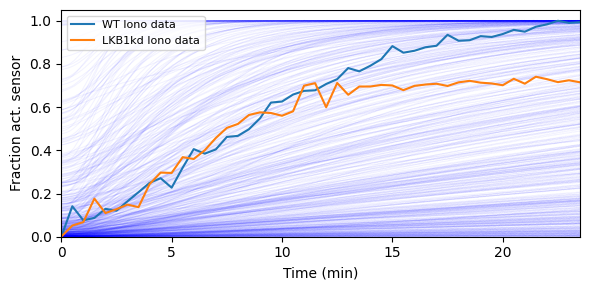

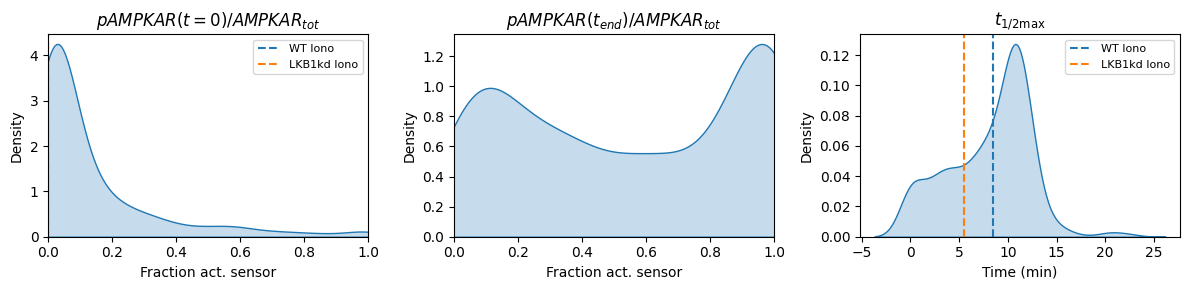

In [5]:
def compute_half_max(arr):
    half_max = arr.max() / 2
    return jnp.argmin(jnp.abs(arr - half_max))

colors = {'wt': 'tab:blue', 'lkb1kd': 'tab:orange'}
preds = np.squeeze(prior_pred.prior_predictive['like'].values[0])
if preds.ndim == 1:
    preds = preds[np.newaxis, :]

# --- Trajectories with both data traces overlaid ---
fig, ax = plt.subplots(figsize=(6, 3))
for i in range(preds.shape[0]):
    ax.plot(iono_times_fine / 60, preds[i], 'b', alpha=0.05, linewidth=0.75)
for key, ds in datasets.items():
    ax.plot(ds['times'], ds['data'].flatten(), markersize=3,
            color=colors[key], label=ds['label'] + ' data', linewidth=1.5)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Fraction act. sensor')
ax.set_xlim([0, iono_times_fine.max() / 60])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MA_nonessential.pdf', bbox_inches='tight')

# --- Density statistics ---
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 3))

# Initial activation
sns.kdeplot(preds[:, 0], ax=axes2[0], fill=True, alpha=0.25)
for key, ds in datasets.items():
    axes2[0].axvline(ds['data'].flatten()[0], color=colors[key], linestyle='--',
                     linewidth=1.5, label=ds['label'])
axes2[0].set_xlabel('Fraction act. sensor')
axes2[0].set_title(r'$pAMPKAR(t=0) / AMPKAR_{tot}$')
axes2[0].set_xlim([0, 1])
axes2[0].legend(fontsize=8)

# Final activation
sns.kdeplot(preds[:, -1], ax=axes2[1], fill=True, alpha=0.25)
axes2[1].set_xlabel('Fraction act. sensor')
axes2[1].set_title(r'$pAMPKAR(t_{end}) / AMPKAR_{tot}$')
axes2[1].set_xlim([0, 1])

# Time to half-max
t_halfs_idxs = jnp.apply_along_axis(compute_half_max, 1, preds)
t_halfs = [iono_times_fine[i] / 60 for i in t_halfs_idxs]
sns.kdeplot(t_halfs, ax=axes2[2], fill=True, alpha=0.25)
for key, ds in datasets.items():
    t_half_data = ds['times'][compute_half_max(ds['data'].flatten())]
    axes2[2].axvline(t_half_data, color=colors[key], linestyle='--',
                     linewidth=1.5, label=ds['label'])
axes2[2].set_xlabel('Time (min)')
axes2[2].set_title(r'$t_{1/2 \max}$')
axes2[2].legend(fontsize=8)

fig2.tight_layout()
fig2.savefig(savedir + 'prior_pred_MA_nonessential_stats.pdf', bbox_inches='tight')

In [6]:
# Compute 95% HDI bounds for GSA sampling and save updated model info
bounds_updated = {}
prior_params_updated = {}
for param in model_info['params']:
    if param in prior_params:
        bounds_updated[param] = list(
            pz.LogNormal(mu=prior_params[param]['mu'], sigma=prior_params[param]['sigma'])
            .hdi(0.95, fmt='.8f')
        )
        prior_params_updated[param] = prior_params[param]
    else:
        bounds_updated[param] = []
        prior_params_updated[param] = {}

model_info['param_bounds'] = bounds_updated
model_info['prior_params'] = prior_params_updated

with open('../models/MA_nonessential.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print('Saved updated model info to MA_nonessential.json')

Saved updated model info to MA_nonessential.json
